# Superdataset Feature Analysis - Predict Item 01
### Predict Item 01 (Has fear of dental work every caused you to put off making an appointment) from DFS 2-20  
**Notes** 
* See `superdataset-feature-analysis-total-score` notebook for some descriptive statistics on the data.
* See `superdataset-feature-analysis-item-20` for inforamation about interpreting results and SHAP values
* Regression models (e.g., Lasso) are not appropriate for predicting Likert values. The data is not continous, e.g., the gap between 1-2 may not be the same as the gap between 4-5.
* The DFS data is skewed. In general, there are more lower values than higher ones. This can be an issue for models that assume normal distribution.
* Models recomended by Claude (sonnet-4.6) to try:
  * Logistic regression as a fast baseline before trying heavier models. Check if LR gets a reasonable kappa (> 0.3).
  * LogisticAT (see https://pythonhosted.org/mord/)
  * LightGBM
  * GradientBoostingClassifier
  * BalancedRandomForest
  * XGBoost

### Summary of model predictions.

| Model | Accuracy | F1 Score (macro)| Cohen Kappa Score (quadradic)|
|:---|:---:|:---:|:---|
| Logistic Regression | 0.66 | 0.46 | 0.77 |
| LogisticAT | 0.58 | 0.47 | 0.76 |
| LightGBM | 0.67 | 0.49 | 0.74 |
| GradientBoostingClassifier | 0.67 | 0.49 | 0.74 |
| BalancedRandomForest | 0.66 | 0.50 | 0.75 |
| XGBoost | 0.68 | 0.50 | 0.75 |

### Understanding the Evaluation Metrics

**Accuracy** is the proportion of respondents whose response was predicted exactly. Every error counts the same, whether the prediction is one level off (4 instead of 5) or four levels off (1 instead of 5). Because it is computed over all respondents, the most common response levels dominate it.

**Macro F1 score** is computed separately for each response level and then averaged, so each level counts equally regardless of how many respondents gave it. For each level, F1 combines *precision* (of the respondents predicted at that level, how many really were) and *recall* (of the respondents at that level, how many were predicted correctly). Rare or hard-to-separate levels pull the macro F1 down, even when overall accuracy is good.

**Cohen Kappa Score (quadratic weighted kappa - QWK)** measures agreement between predicted and actual responses beyond what chance would produce. It penalizes errors by the square of their distance, so a prediction two levels off costs four times as much as one level off. It ranges from −1 to 1, where 0 is chance-level agreement and 1 is perfect agreement. QWK is the most appropriate of the three for an ordinal Likert target, because it recognizes that predicting 4 for a true 5 is a smaller mistake than predicting 1.


### Why the scores differ

- **Macro F1 (~0.46–0.50) is much lower than accuracy (~0.66).** The models predict the common response levels well but struggle with the rare or middle ones, and macro F1 weights those levels equally.
- **QWK (~0.74–0.77) is the highest.** Most errors are near misses between adjacent response levels, which QWK penalizes only lightly.
- **LogisticAT has lower accuracy (0.58) but similar QWK (0.76).** It makes more exact-match errors, but those errors are mostly one level off, which fits a model that treats the response scale as ordered.

### Model Recommendation

All six models perform similarly. Accuracy ranges from 0.58 to 0.68, macro F1 from 0.46 to 0.50, and quadratic weighted kappa (QWK) from 0.74 to 0.77. Differences of 0.01–0.04 are small enough that they likely reflect which respondents ended up in the test set rather than real differences between models. The one exception is LogisticAT's accuracy (0.58), which is noticeably lower than the others.

**Recommended model: Logistic Regression.**

- **It has the highest Cohen Kappa Score (QWK) (0.77).** QWK is the most appropriate metric for an ordinal Likert target, because it gives partial credit for near misses.
- **Its accuracy (0.66) and macro F1 (0.46) are close to the best models**, which score at most 0.68 and 0.50.
- **It is the simplest and most interpretable model.** Its coefficients show directly how each item relates to each response level. The tree-based ensembles (LightGBM, GradientBoostingClassifier, BalancedRandomForest, XGBoost) add complexity and require SHAP for interpretation, without a meaningful gain in performance.

XGBoost has the highest accuracy and F1 by small margins, but these gains do not justify the added complexity. When models perform equivalently, the simpler model is preferred.

**Alternative:** LogisticAT's QWK (0.76) is essentially tied with Logistic Regression's, and it treats the response scale as ordered. It gives a single coefficient per item, interpreted as a shift up or down the response scale. If interpretability matters more than exact-match accuracy, it is a reasonable choice.

### Model Feature Rankings  

*LR = LogisticRegression; LRAT = LogisticAT; LGB = LightGBM; GBC = GradientBoostingClassifier; BRF = BalancedRandomForest; XGB = XGBoost*

#### Native Feature Rankings (e.g., coefficients, information gain)
| Rank | Feature | No. of Models | Models |
|:---:|:---|:---:|:---|
| 1 | dfs2  | 5 | LR, LRAT, LGB, GBC, BRF |
|   | dfs20 | 1 | XGB |
| 2 | dfs20 | 5 | LR, LRAT, LGB, GBC, BRF |
|   | dfs2  | 1 | XGB |
| 3 | dfs11 | 4 | LGB, GBC, BRF, XGB |
|   | dfs8  | 2 | LR, LRAT |
| 4 | dfs8  | 4 | LGB, GBC, BRF, XGB |
|   | dfs11 | 2 | LR, LRAT |
| 5 | dfs9  | 4 | LRAT, LGB, GBC, BRF |
|   | dfs15 | 1 | LR |
|   | dfs10 | 1 | XGB |

#### SHAP Feature Rankings
| Rank | Feature | No. of Models | Models |
|:---:|:---|:---:|:---|
| 1 | dfs20 | 4 | LRAT, GBC, BRF, XGB |
|   | dfs2  | 2 | LR, LGB |
| 2 | dfs2  | 4 | LRAT, GBC, BRF, XGB |
|   | dfs20 | 2 | LR, LGB |
| 3 | dfs8  | 5 | LR, LRAT, LGB, GBC, XGB |
|   | dfs11 | 1 | BRF |
| 4 | dfs11 | 4 | LRAT, LGB, GBC, XGB |
|   | dfs15 | 1 | LR |
|   | dfs8  | 1 | BRF |
| 5 | dfs15 | 3 | LGB, GBC, XGB |
|   | dfs11 | 1 | LR |
|   | dfs14 | 1 | LRAT |
|   | dfs9  | 1 | BRF |


### DFS Questions
**DFS 01**: Has fear of dental work every caused you to put off making an appointment? 
**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 03**: When having dental work done *my muscles become tense*.  
**DFS 04**: When having dental work done *my breathing rate increases*.   
**DFS 05**: When having dental work done *I prespire*.  
**DFS 06**: When having dental work done *I feel nauseated and sick to my stomach*.  
**DFS 07**: When having dental work done *my heart beats faster*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 10**: Please rate how much fear, anxiety, or unpleasantness for *sitting in the waiting room*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 12**: Please rate how much fear, anxiety, or unpleasantness for *the smell of the dentist's office*.  
**DFS 13**: Please rate how much fear, anxiety, or unpleasantness for *seeing the dentist walk in*.  
**DFS 14**: Please rate how much fear, anxiety, or unpleasantness for *seeing the anesthetic needle*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 18**: Please rate how much fear, anxiety, or unpleasantness for *feeling the vibrations of the drill*.  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
**DFS 20**: All things considered, how fearful are you of having dental work done?   

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# keeps warnings from printing
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')# suppress all warnings
# if you want more targeted:
# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [3]:
import pandas as pd
import numpy as np
from lib.superdataset_utils import load_dfs_subset, DFS_QUESTION_COLS
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import textwrap
import random
import sklearn
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import \
    confusion_matrix, classification_report, cohen_kappa_score, balanced_accuracy_score, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform, loguniform, spearmanr
import xgboost as xgb
import lightgbm as lgb
import shap
from mord import LogisticAT

In [4]:
print(f'sklearn version: {sklearn.__version__}')
print(f'xgb version: {xgb.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')
print(f'shap version: {shap.__version__}')

sklearn version: 1.9.1
xgb version: 3.1.3
pandas version: 2.3.3
numpy version: 2.4.6
shap version: 0.50.0


---

## Load superdataset

In [5]:
super_df = load_dfs_subset('./DFA-data/merged_dfa_data_cleaned_2026_09_17.csv')
super_df.shape

(4250, 28)

In [6]:
super_df.head()

,Participant_id,Last_Dental_Visit,Sex,Age,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,...,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20,dfs_avoidance_fear,dfs_specific_stimuli_fear,dfs_physiological_arousal,dfs_total_score
0,1,1,2,44,3,3,4,5,5,1,...,5,5,5,5,1,5,18,26,20,69
1,2,1,2,56,1,1,3,1,1,1,...,2,4,4,4,1,1,8,17,7,33
2,3,1,2,72,1,1,1,1,1,1,...,3,1,1,1,1,1,8,11,5,25
3,6,1,2,36,1,1,1,1,1,1,...,3,3,3,3,1,1,8,16,5,30
4,7,1,2,39,1,1,1,1,1,1,...,1,2,2,2,1,1,8,9,5,23


In [7]:
# subset data to dfs questions
subset_df = super_df[DFS_QUESTION_COLS]
subset_df.shape

(4250, 20)

In [8]:
subset_df.head()

,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,dfs7,dfs8,dfs9,dfs10,dfs11,dfs12,dfs13,dfs14,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20
0,3,3,4,5,5,1,5,2,2,2,2,2,2,5,5,5,5,5,1,5
1,1,1,3,1,1,1,1,1,1,1,1,1,1,2,2,4,4,4,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,4,3,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,1,1


---

## Create train and test data

In [9]:
X = subset_df.drop('dfs1', axis=1)
y = subset_df['dfs1']

In [10]:
# note the use of `stratify=y` so every response level is represented in the test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
print(f'len(X_train): {len(X_train)}, len(y_train): {len(y_train)}')
print(f'len(X_test): {len(X_test)}, len(y_test): {len(y_test)}')

len(X_train): 2847, len(y_train): 2847
len(X_test): 1403, len(y_test): 1403


**note**: the data is skewed

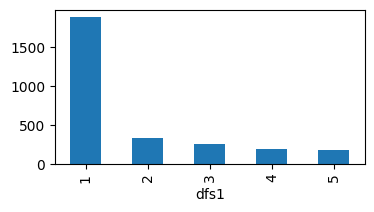

In [11]:
plt.figure(figsize=(4, 2)) # width, height in inches
y_train.value_counts().sort_index().plot(kind='bar')
plt.show()

---

## Logistic Regression  
Check if LR gets a reasonable kappa (> 0.3).

In [12]:
lr_param_dist = {
    'C': loguniform(0.001, 100),  # inverse regularization, log scale is important
    'solver': ['lbfgs', 'saga'],  # both support multinomial
}

In [13]:
lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_distributions=lr_param_dist,
    n_iter=20,
    cv=3,
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [14]:
lr_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....t 0x1286dae10>, 'solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_result

In [15]:
lr_model = lr_search.best_estimator_

In [16]:
lr_best_score = lr_search.best_score_
lr_best_params = lr_search.best_params_

In [17]:
print("Best LR balanced_accuracy score:", lr_best_score) # 0.55 – 0.70 is a moderate score
print("Best LR params:", lr_best_params)

Best LR balanced_accuracy score: 0.45523219648219654
Best LR params: {'C': np.float64(0.37253938395788866), 'solver': 'saga'}


In [18]:
lr_model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0....3938395788866)
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: bot

In [19]:
y_pred = lr_model.predict(X_test)

### classification report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.90      0.80      0.85       931
           2       0.25      0.35      0.29       165
           3       0.21      0.19      0.20       125
           4       0.33      0.52      0.40        93
           5       0.59      0.52      0.55        89

    accuracy                           0.66      1403
   macro avg       0.46      0.48      0.46      1403
weighted avg       0.70      0.66      0.68      1403



In [21]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.66
Macro F1:              0.46
Weighted F1:           0.68
Micro F1:              0.66
Within ±1 accuracy:    0.92
Quadratic weighted κ:  0.77


### confusion matrix

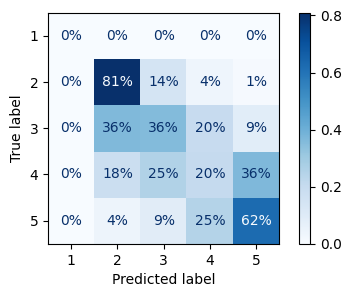

In [22]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance based on coeficients

In [23]:
lr_mean_abs_coef = np.abs(lr_search.best_estimator_.coef_).mean(axis=0)
lr_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lr_mean_abs_coef
}).sort_values('importance', ascending=False)

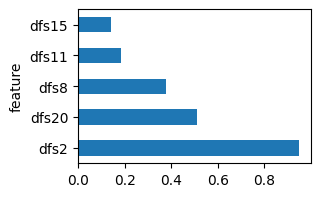

In [24]:
lr_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.show()

**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   

### shap importance

In [25]:
lr_explainer = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)

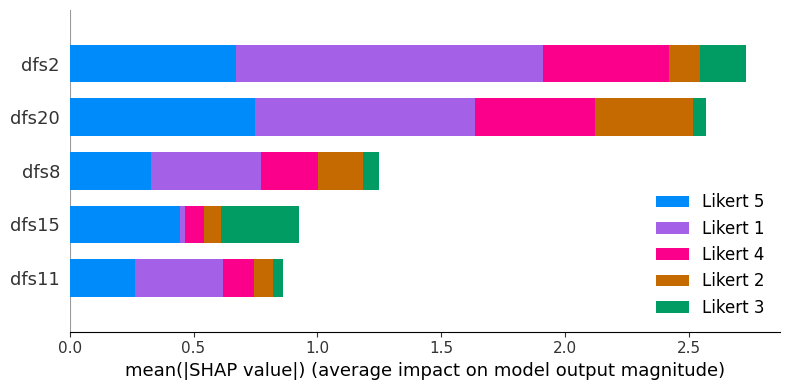

In [26]:
shap.summary_plot(
    lr_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(8, 4),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  

---

## LogisticAT

In [27]:
lrat_param_dist = {
    'alpha': loguniform(0.001, 100),  # regularization strength (NOT inverse like C), log scale
    'max_iter': [1000, 5000],
}

In [28]:
lrat_search = RandomizedSearchCV(
    estimator=LogisticAT(),
    param_distributions=lrat_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [29]:
# LogisticAT has no class_weight; pass balanced sample weights to mimic class_weight='balanced'
lrat_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
lrat_search.fit(X_train, y_train, sample_weight=lrat_sample_weight)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticAT()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': <scipy.stats....t 0x1286ff8d0>, 'max_iter': [1000, 5000]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the

In [30]:
lrat_model = lrat_search.best_estimator_

In [31]:
lrat_best_score = lrat_search.best_score_
lrat_best_params = lrat_search.best_params_

In [32]:
print("Best LRAT balanced_accuracy score:", lrat_best_score) # 0.55 – 0.70 is a moderate score
print("Best LRAT params:", lrat_best_params)

Best LRAT balanced_accuracy score: 0.49032961532961533
Best LRAT params: {'alpha': np.float64(14.528246637516036), 'max_iter': 5000}


In [33]:
y_pred = lrat_model.predict(X_test)

In [34]:
y_pred = lrat_model.predict(X_test)

### classification report

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.63      0.76       931
           2       0.23      0.61      0.33       165
           3       0.23      0.26      0.25       125
           4       0.33      0.42      0.37        93
           5       0.67      0.64      0.66        89

    accuracy                           0.58      1403
   macro avg       0.48      0.51      0.47      1403
weighted avg       0.75      0.58      0.63      1403



In [36]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.58
Macro F1:              0.47
Weighted F1:           0.63
Micro F1:              0.58
Within ±1 accuracy:    0.93
Quadratic weighted κ:  0.76


### confusion matrix

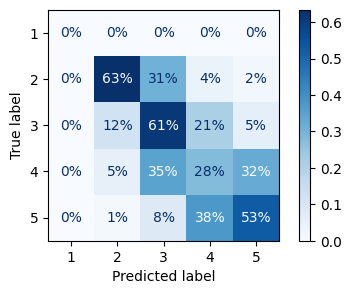

In [37]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance based on coeficients

In [38]:
lrat_coef = lrat_search.best_estimator_.coef_
lrat_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lrat_coef,
    'importance': np.abs(lrat_coef),
}).sort_values('importance', ascending=False)

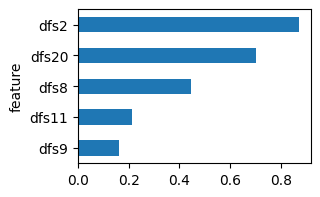

In [39]:
lrat_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()  # most important at the top
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

### shap importance

In [40]:
# lrat_masker tells SHAP what to substitute for a feature when it measures what happens without that feature.
lrat_masker = shap.maskers.Independent(X_train, max_samples=100)

In [41]:
def lrat_latent(X):
    return np.asarray(X) @ lrat_model.coef_

In [42]:
lrat_explainer = shap.Explainer(
    lrat_latent, lrat_masker,
    feature_names=X_train.columns.tolist(),
)
lrat_shap_values = lrat_explainer(X_test)

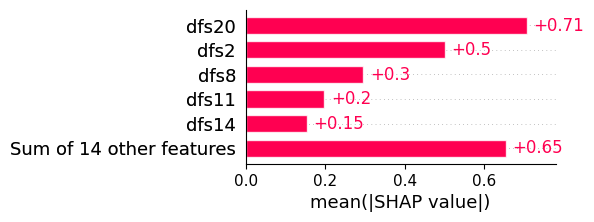

In [43]:
fig, ax = plt.subplots(figsize=(4, 2))
shap.plots.bar(lrat_shap_values, max_display=6, ax=ax, show=False)
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 14**: Please rate how much fear, anxiety, or unpleasantness for *seeing the anesthetic needle*.   

---

## LightGBM

In [44]:
lgbm_param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': loguniform(0.005, 0.2),
    'num_leaves': randint(4, 32),            # main complexity control; keep small for survey-sized data
    'max_depth': [-1, 3, 4, 5, 6],
    'min_child_samples': randint(5, 50),     # min respondents per leaf
    'subsample': uniform(0.6, 0.4),          # 0.6–1.0, row bagging
    'subsample_freq': [1],                   # needed for subsample to take effect
    'colsample_bytree': uniform(0.5, 0.5),   # 0.5–1.0, feature bagging
    'reg_alpha': loguniform(1e-3, 10),       # L1
    'reg_lambda': loguniform(1e-3, 10),      # L2
}

In [45]:
lgbm_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        objective='multiclass',
        class_weight='balanced',
        random_state=42,
        n_jobs=1,        # let the search parallelize across fits instead
        verbose=-1,      # silence LightGBM's per-fit logging
    ),
    param_distributions=lgbm_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [46]:
lgbm_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x12a507750>, 'learning_rate': <scipy.stats....t 0x129b2bf50>, 'max_depth': [-1, 3, ...], 'min_child_samples': <scipy.stats....t 0x12a5102d0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations o

In [47]:
lgbm_model = lgbm_search.best_estimator_

In [48]:
lgbm_best_score = lgbm_search.best_score_
lgbm_best_params = lgbm_search.best_params_

In [49]:
print("Best LGB score:", lgbm_best_score)
print("Best LGB params:", lgbm_best_params)

Best LGB score: 0.5368739274989275
Best LGB params: {'colsample_bytree': np.float64(0.6143990827458112), 'learning_rate': np.float64(0.006641962786482821), 'max_depth': 4, 'min_child_samples': 26, 'n_estimators': 895, 'num_leaves': 5, 'reg_alpha': np.float64(0.3143519744713589), 'reg_lambda': np.float64(0.015224209209544584), 'subsample': np.float64(0.6421977039321082), 'subsample_freq': 1}


In [50]:
lgbm_model.fit(X_train, y_train)

,num_leaves,5
,max_depth,4
,learning_rate,np.float64(0....1962786482821)
,n_estimators,895
,objective,'multiclass'
,class_weight,'balanced'
,min_child_samples,26
,subsample,np.float64(0.6421977039321082)
,subsample_freq,1
,colsample_bytree,np.float64(0.6143990827458112)
,reg_alpha,np.float64(0.3143519744713589)


In [51]:
y_pred = lgbm_model.predict(X_test)

### classification reprort

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.91      0.79      0.85       931
           2       0.30      0.48      0.37       165
           3       0.30      0.34      0.32       125
           4       0.40      0.38      0.39        93
           5       0.52      0.56      0.54        89

    accuracy                           0.67      1403
   macro avg       0.49      0.51      0.49      1403
weighted avg       0.72      0.67      0.69      1403



In [53]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.67
Macro F1:              0.49
Weighted F1:           0.69
Micro F1:              0.67
Within ±1 accuracy:    0.91
Quadratic weighted κ:  0.74


### confusion matrix

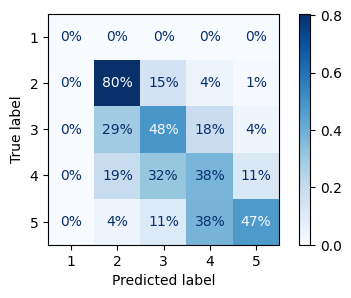

In [54]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance based on coeficients¶

In [55]:
lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

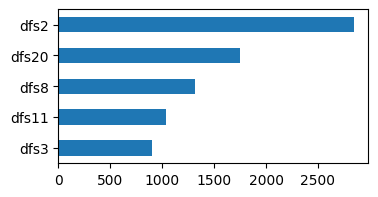

In [56]:
lgbm_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 03**: When having dental work done *my muscles become tense*.  

### shap importances

In [57]:
lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer(X_test)

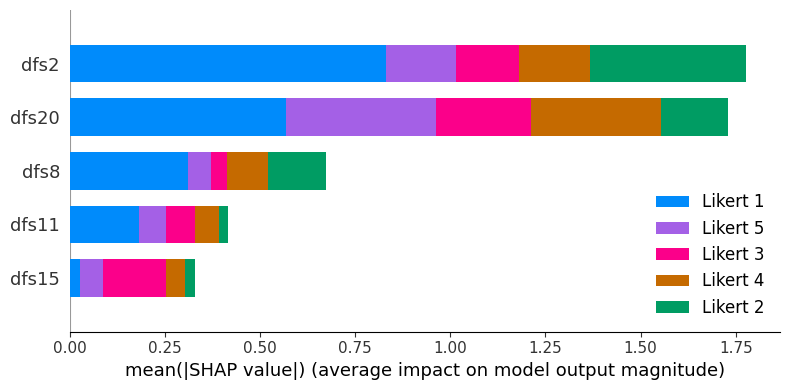

In [58]:
shap.summary_plot(
    lgbm_shap_values, 
    X_test, plot_type='bar',
    max_display=5, 
    plot_size=(8, 4), 
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  

---

## GradientBoostingClassifier

In [59]:
gbc_param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': loguniform(0.01, 0.2),
    'max_depth': randint(2, 6),              # shallow trees; main complexity control
    'min_samples_leaf': randint(5, 50),      # min respondents per leaf
    'min_samples_split': randint(10, 100),
    'subsample': uniform(0.6, 0.4),          # 0.6–1.0; <1.0 = stochastic gradient boosting
    'max_features': ['sqrt', 'log2', None],
}

In [60]:
gbc_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gbc_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [61]:
# GradientBoostingClassifier has no class_weight; balanced sample weights mimic it
gbc_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
gbc_search.fit(X_train, y_train, sample_weight=gbc_sample_weight)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....t 0x12a64d9d0>, 'max_depth': <scipy.stats....t 0x12a661010>, 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x12a676810>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations

In [62]:
gbc_model = gbc_search.best_estimator_

In [63]:
gbc_best_score = gbc_search.best_score_
gbc_best_params = gbc_search.best_params_

In [64]:
print("Best GBC score:", gbc_best_score)
print("Best GBC params:", gbc_best_params)

Best GBC score: 0.5279433004433003
Best GBC params: {'learning_rate': np.float64(0.023042383910649448), 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 23, 'min_samples_split': 11, 'n_estimators': 152, 'subsample': np.float64(0.7957811041110252)}


In [65]:
y_pred = gbc_model.predict(X_test)

### classification reprort

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.91      0.78      0.84       931
           2       0.30      0.52      0.38       165
           3       0.30      0.30      0.30       125
           4       0.41      0.42      0.41        93
           5       0.51      0.56      0.53        89

    accuracy                           0.67      1403
   macro avg       0.49      0.52      0.49      1403
weighted avg       0.73      0.67      0.69      1403



In [67]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.67
Macro F1:              0.49
Weighted F1:           0.69
Micro F1:              0.67
Within ±1 accuracy:    0.91
Quadratic weighted κ:  0.74


### confusion matrix

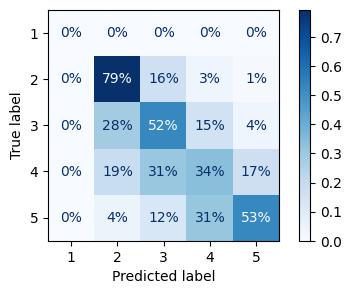

In [68]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance  

In [69]:
gbc_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gbc_model.feature_importances_,
}).sort_values('importance', ascending=False)

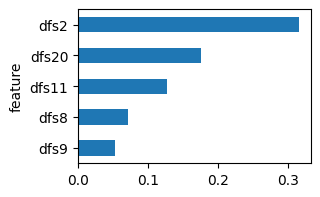

In [70]:
gbc_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

## shap importance  
GradientBoostingClassifier is only supported for binary classification right now. For your five-class model, use the model-agnostic explainer on the model's raw class scores.

In [71]:
gbc_masker = shap.maskers.Independent(X_train, max_samples=100)

In [72]:
def gbc_raw_scores(X):
    # rebuild a DataFrame so sklearn doesn't warn about missing feature names
    X = pd.DataFrame(np.asarray(X), columns=X_train.columns)
    return gbc_model.decision_function(X)   # shape (n, 5): raw per-class scores

In [73]:
gbc_explainer = shap.Explainer(
    gbc_raw_scores, gbc_masker,
    feature_names=X_train.columns.tolist(),
    output_names=[f"Likert {k + 1}" for k in range(5)],
)
gbc_shap_values = gbc_explainer(X_test)   # shape (n, features, 5)

PermutationExplainer explainer: 1404it [01:53, 11.35it/s]                                                               


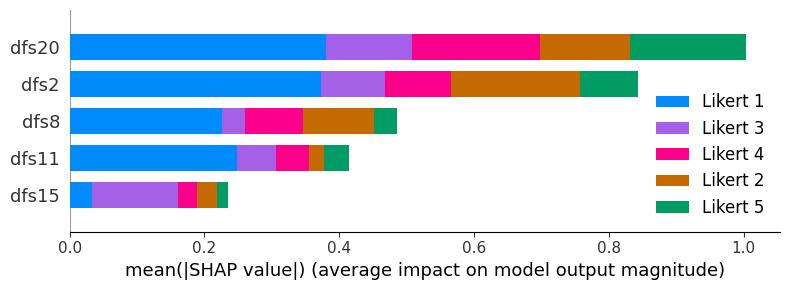

In [74]:
shap.summary_plot(
    gbc_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, plot_size=(8, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  

----

## BalancedRandomForest

In [75]:
brf_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': [None, 4, 6, 8, 12],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 30),
    'max_features': ['sqrt', 'log2', 0.5],
    'sampling_strategy': ['all', 'not minority'],
}

In [76]:
brf_search = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(
        replacement=True,
        bootstrap=False,     # set explicitly: imblearn's defaults changed in 0.13
        random_state=42,
        n_jobs=1,
    ),
    param_distributions=brf_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [77]:
brf_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BalancedRando...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x12a2548d0>, 'min_samples_split': <scipy.stats....t 0x129f34c50>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than 

In [78]:
brf_model = brf_search.best_estimator_

In [79]:
brf_best_score = brf_search.best_score_
brf_best_params = brf_search.best_params_

In [80]:
print("Best BRF score:", brf_best_score)
print("Best BRF params:", brf_best_params)

Best BRF score: 0.5301812526812527
Best BRF params: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 11, 'min_samples_split': 5, 'n_estimators': 624, 'sampling_strategy': 'not minority'}


In [81]:
y_pred = brf_model.predict(X_test)

### classification reprort

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.93      0.76      0.83       931
           2       0.30      0.56      0.39       165
           3       0.27      0.33      0.30       125
           4       0.43      0.41      0.42        93
           5       0.54      0.56      0.55        89

    accuracy                           0.66      1403
   macro avg       0.49      0.52      0.50      1403
weighted avg       0.74      0.66      0.69      1403



In [83]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.66
Macro F1:              0.50
Weighted F1:           0.69
Micro F1:              0.66
Within ±1 accuracy:    0.92
Quadratic weighted κ:  0.75


### confusion matrix

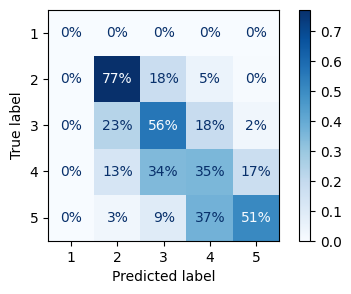

In [84]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance  
A random forest has no coefficients. The closest equivalent is feature_importances_, which measures how much each feature reduces impurity across all the trees. It is always non-negative and shows no direction

In [85]:
brf_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': brf_model.feature_importances_,
}).sort_values('importance', ascending=False)

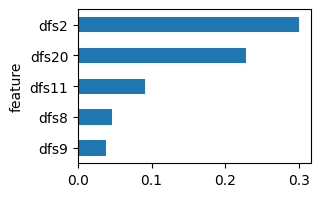

In [86]:
brf_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

### shap importances

In [87]:
brf_explainer = shap.TreeExplainer(brf_model)
brf_shap_values = brf_explainer(X_test)

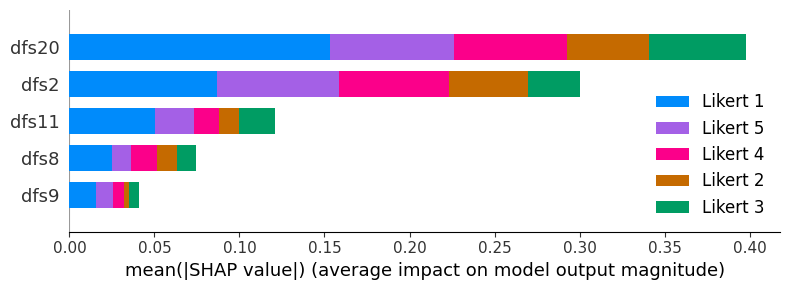

In [88]:
shap.summary_plot(
    brf_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(8, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

---

## XGBoost

In [89]:
xgb_param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': loguniform(0.005, 0.2),
    'max_depth': randint(2, 7),
    'min_child_weight': loguniform(0.5, 20),   # min weighted respondents per leaf
    'subsample': uniform(0.6, 0.4),            # 0.6–1.0
    'colsample_bytree': uniform(0.5, 0.5),     # 0.5–1.0
    'gamma': loguniform(1e-3, 5),              # min loss reduction to split
    'reg_alpha': loguniform(1e-3, 10),         # L1
    'reg_lambda': loguniform(1e-3, 10),        # L2
}

In [90]:
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=1,          # let the search parallelize across fits
    ),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [91]:
# XGBoost requires class labels to be the consecutive integers 0 to K−1, and the other models don't. If you'd rather keep y as 1–5 for everything else, shift the labels for XGBoost alone:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [92]:
# XGBoost has no class_weight; balanced sample weights mimic it
xgb_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_xgb)
xgb_search.fit(X_train, y_train_xgb, sample_weight=xgb_sample_weight)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x12a1f9010>, 'gamma': <scipy.stats....t 0x129a0b710>, 'learning_rate': <scipy.stats....t 0x12a009f50>, 'max_depth': <scipy.stats....t 0x129b4ca90>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerat

In [93]:
xgb_model = xgb_search.best_estimator_

In [94]:
xgb_best_score = xgb_search.best_score_
xgb_best_params = xgb_search.best_params_

In [95]:
print("Best XGB score:", xgb_best_score)
print("Best XGB params:", xgb_best_params)

Best XGB score: 0.5421760153010151
Best XGB params: {'colsample_bytree': np.float64(0.6379995910112717), 'gamma': np.float64(0.012471158839664204), 'learning_rate': np.float64(0.009198935109497567), 'max_depth': 2, 'min_child_weight': np.float64(19.055576023698443), 'n_estimators': 443, 'reg_alpha': np.float64(0.03797747379173691), 'reg_lambda': np.float64(0.014926318309209369), 'subsample': np.float64(0.6056319290860338)}


In [96]:
# Shift the predictions back so they're on the same 1–5 scale as the other models.
xgb_y_pred = xgb_model.predict(X_test) + 1
xgb_labels = np.unique(np.concatenate([np.asarray(y_test), xgb_y_pred]))

## classification report

In [97]:
print(classification_report(y_test, xgb_y_pred, labels=xgb_labels))

              precision    recall  f1-score   support

           1       0.91      0.79      0.85       931
           2       0.31      0.57      0.40       165
           3       0.34      0.26      0.29       125
           4       0.40      0.44      0.42        93
           5       0.52      0.54      0.53        89

    accuracy                           0.68      1403
   macro avg       0.50      0.52      0.50      1403
weighted avg       0.73      0.68      0.70      1403



In [98]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.66
Macro F1:              0.50
Weighted F1:           0.69
Micro F1:              0.66
Within ±1 accuracy:    0.92
Quadratic weighted κ:  0.75


### confusion matrix

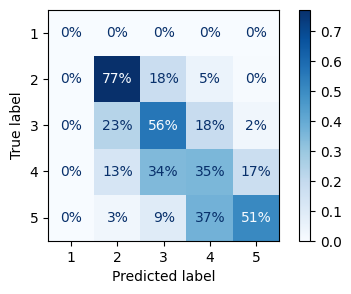

In [99]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance

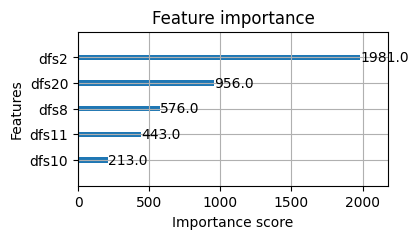

In [100]:
# Plot importance using default weight/gain
fig, ax = plt.subplots(figsize=(4, 2))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=5)
plt.show()

**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 10**: Please rate how much fear, anxiety, or unpleasantness for *sitting in the waiting room*.  

### shap importances

In [101]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_test)   # shape (n, features, 5), per-class log-odds

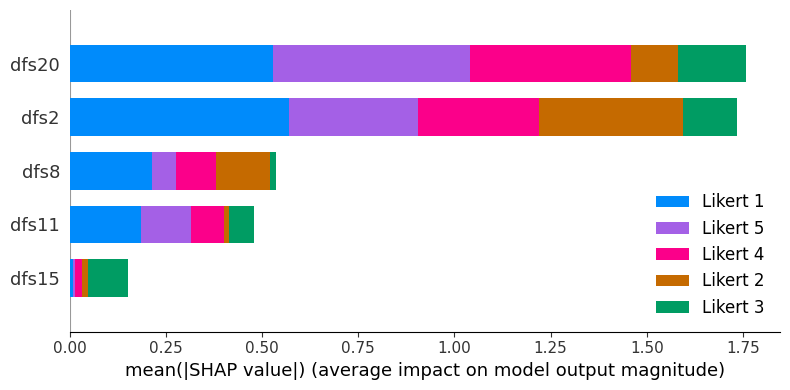

In [102]:
shap.summary_plot(
    xgb_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(8, 4),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  

---

## Compare and Visualize Results

In [103]:
from lib.superdataset_utils import (
    shap_ranking, 
    native_ranking, 
    rank_feature_counts_long, 
    compare_top_n_counts, 
    plot_top_n_counts, 
    build_feature_color_map, 
    style_rank_table,
    rank_position_counts,
    top_n_feature_counts,
    rank_feature_counts_long,
    bar_plot_rank_composition,
    plot_rank_heatmap,
    plot_rank_heatmaps_side_by_side,
    build_model_annotations,
    align_rank_counts
)   

In [104]:
# dict of model abbreviations
model_abbrev = {
    "LogisticRegression": "LR",
    "LogisticAT": "LRAT",
    "LightGBM": "LGB",
    "GradientBoostingClassifier": "GBC",
    "BalancedRandomForest": "BRF",
    "XGBoost": "XGB"
}

In [105]:
# For each model, get features sorted by importance (most important first)
shap_rankings = {
    'LogisticRegression':         shap_ranking(lr_shap_values,   X_test.columns),
    'LogisticAT':                 shap_ranking(lrat_shap_values, X_test.columns),
    'LightGBM':                   shap_ranking(lgbm_shap_values, X_test.columns),
    'GradientBoostingClassifier': shap_ranking(gbc_shap_values,  X_test.columns),
    'BalancedRandomForest':       shap_ranking(brf_shap_values,  X_test.columns),
    'XGBoost':                    shap_ranking(xgb_shap_values,  X_test.columns),
}

In [106]:
# Build a table: rows = rank (1st, 2nd, 3rd...), columns = model
shap_rank_df = pd.DataFrame(shap_rankings)
shap_rank_df.index = shap_rank_df.index + 1
shap_rank_df.index.name = 'Rank'
shap_rank_df.head()

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs2,dfs20,dfs2,dfs20,dfs20,dfs20
2,dfs20,dfs2,dfs20,dfs2,dfs2,dfs2
3,dfs8,dfs8,dfs8,dfs8,dfs11,dfs8
4,dfs15,dfs11,dfs11,dfs11,dfs8,dfs11
5,dfs11,dfs14,dfs15,dfs15,dfs9,dfs15


### compare Native Feature Importances (e.g., coeficients)

In [107]:
native_rankings = {
    'LogisticRegression':         native_ranking(lr_model.coef_, X_train.columns),     # mean |coef| across classes
    'LogisticAT':                 native_ranking(lrat_model.coef_, X_train.columns),   # single shared coef vector
    'LightGBM':                   native_ranking(lgbm_model.booster_.feature_importance(importance_type='gain'), X_train.columns),
    'GradientBoostingClassifier': native_ranking(gbc_model.feature_importances_, X_train.columns),  # impurity-based
    'BalancedRandomForest':       native_ranking(brf_model.feature_importances_, X_train.columns),  # impurity-based
    'XGBoost':                    native_ranking(xgb_model.feature_importances_, X_train.columns),  # gain by default
}

In [108]:
native_rank_df = pd.DataFrame(native_rankings)
native_rank_df.index = native_rank_df.index + 1
native_rank_df.index.name = 'Rank'
native_rank_df.head()

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs2,dfs2,dfs2,dfs2,dfs2,dfs20
2,dfs20,dfs20,dfs20,dfs20,dfs20,dfs2
3,dfs8,dfs8,dfs11,dfs11,dfs11,dfs11
4,dfs11,dfs11,dfs8,dfs8,dfs8,dfs8
5,dfs15,dfs9,dfs9,dfs9,dfs9,dfs10


In [109]:
native_value_counts = pd.Series(native_rank_df.head(3).values.ravel()).value_counts()
native_value_counts

dfs2     6
dfs20    6
dfs11    4
dfs8     2
Name: count, dtype: int64

In [110]:
# uncomment to see table with columns "Rank, Feature, Count, Models"
# rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)

In [111]:
# uncomment to native vs shap counts
# comparison = compare_top_n_counts(native_rank_df, shap_rank_df, top_n=5, names=('native', 'shap'))
# comparison

### visualizations

In [112]:
feature_color_map = build_feature_color_map(native_rank_df, shap_rank_df, softness=0.7)

In [113]:
style_rank_table(shap_rank_df.head(), feature_color_map)

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs2,dfs20,dfs2,dfs20,dfs20,dfs20
2,dfs20,dfs2,dfs20,dfs2,dfs2,dfs2
3,dfs8,dfs8,dfs8,dfs8,dfs11,dfs8
4,dfs15,dfs11,dfs11,dfs11,dfs8,dfs11
5,dfs11,dfs14,dfs15,dfs15,dfs9,dfs15


In [114]:
style_rank_table(native_rank_df.head(), feature_color_map)

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs2,dfs2,dfs2,dfs2,dfs2,dfs20
2,dfs20,dfs20,dfs20,dfs20,dfs20,dfs2
3,dfs8,dfs8,dfs11,dfs11,dfs11,dfs11
4,dfs11,dfs11,dfs8,dfs8,dfs8,dfs8
5,dfs15,dfs9,dfs9,dfs9,dfs9,dfs10


In [115]:
# rank_position_counts(native_rank_df)  

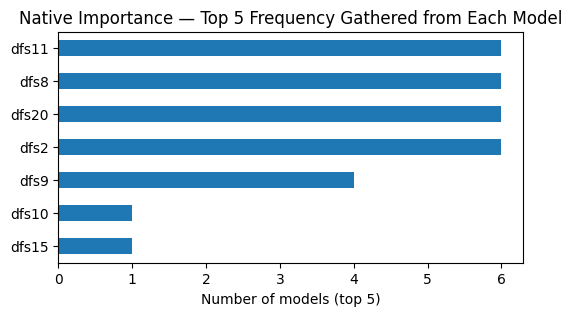

In [116]:
native_top5 = top_n_feature_counts(native_rank_df, top_n=5)
plot_top_n_counts(native_top5, top_n=5, title='Native Importance — Top 5 Frequency Gathered from Each Model')

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  
**DFS 20**: All things considered, how fearful are you of having dental work done?   
**DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 10**: Please rate how much fear, anxiety, or unpleasantness for *sitting in the waiting room*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  

## native rankings

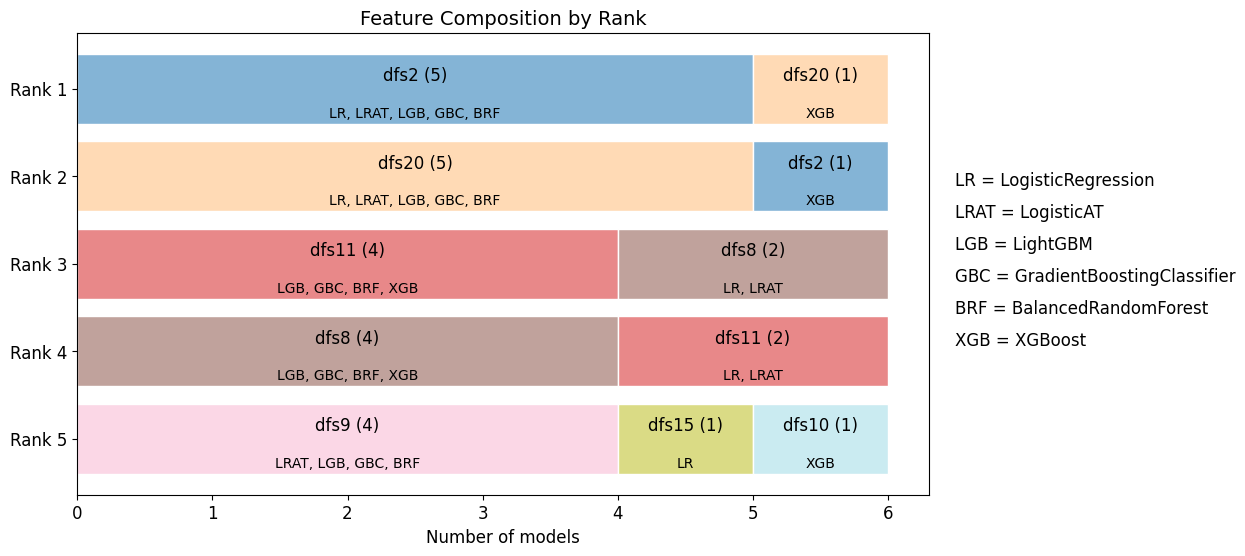

In [117]:
native_long = rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(native_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

**Rank 1**  
* **DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
* **DFS 20**: All things considered, how fearful are you of having dental work done?   

**Rank 2**  
* **DFS 20**: All things considered, how fearful are you of having dental work done?   
* **DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   

**Rank 3**  
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.
* **DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.  

**Rank 4**  
* **DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.

**Rank 5**  
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.
* **DFS 10**: Please rate how much fear, anxiety, or unpleasantness for *sitting in the waiting room*.  

## shap rankings

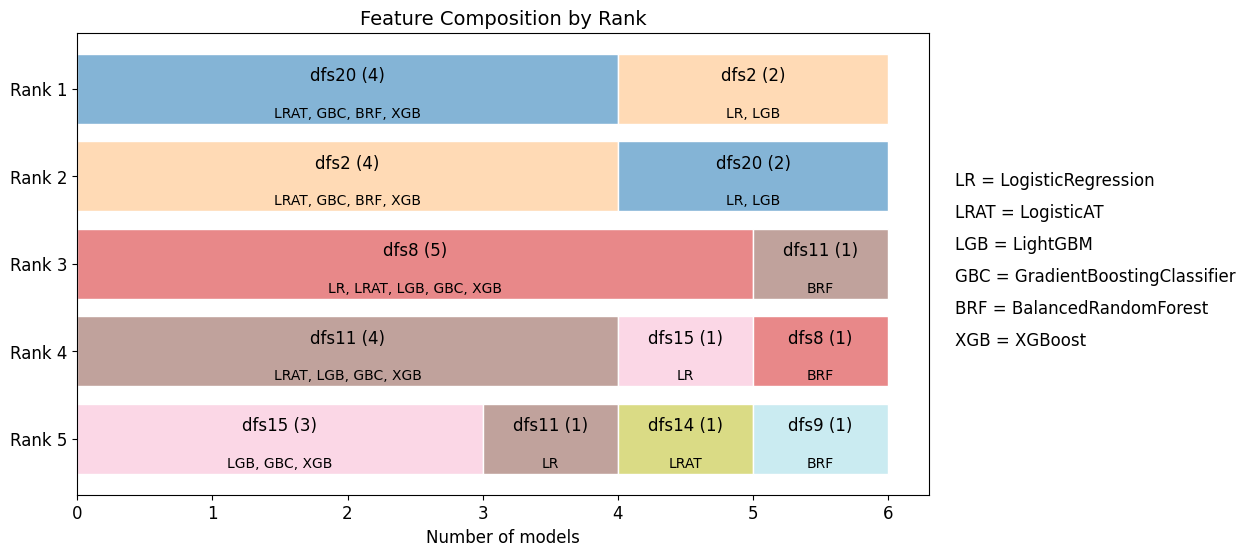

In [118]:
shap_long = rank_feature_counts_long(shap_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(shap_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

**Rank 1**  
* **DFS 20**: All things considered, how fearful are you of having dental work done?   
* **DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   

**Rank 2**  
* **DFS 02**: Has fear of dental work every caused you to cancel or not appear for an appointment.   
* **DFS 20**: All things considered, how fearful are you of having dental work done?   

**Rank 3**  
* **DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.

**Rank 4**  
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
* **DFS 08**: Please rate how much fear, anxiety, or unpleasantness for *making an appointment for dentistry*.

**Rank 5**  
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.
* **DFS 14**: Please rate how much fear, anxiety, or unpleasantness for *seeing the anesthetic needle*.  
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.